In [1]:
#utils I made to look at this data
import numpy as np
import sys
import os
import time
import random
import copy
import math
%matplotlib inline
from matplotlib import pyplot as plt
import matplotlib as mpl
import pandas as pd
import seaborn as sns
import scanpy as sc
import autoreload
params = {
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'font.family': "Helvetica",
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 300
   }

mpl.rcParams.update(params)

sns.set_style("ticks")

savefig_args = {"dpi": 300, "bbox_inches": "tight", "pad_inches": 0, "transparent": True}
mpl.rc('savefig', dpi=300)
output_dir = "figures/ClonalGenesCorrelations"
output_suffix = ""
output_formats = [".png", ".pdf"]

def save_figure(fig, name, output_dir=output_dir, output_suffix=output_suffix, output_formats=output_formats, savefig_args=savefig_args):
    for output_format in output_formats:
        fig.savefig(output_dir + "/" + name + output_suffix + output_format, **savefig_args)
    return None

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

## Load Data

In [2]:
adata = sc.read_h5ad('/home/mswift/B_cells/CSR/switchy/data/CombinedDivisionImmcantation.h5ad')

OSError: Unable to open file (unable to open file: name = '/home/mswift/B_cells/CSR/switchy/data/Combined_PC_Changeo_Flow.h5ad', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

## Enumerate all of the expected plates and fluorescence



In [3]:
adata.obs['Sort'].value_counts()

None                2589
1st_peak             603
IgG+,IgE+,CD19+      502
Reg_IL_split         497
CTV+2                373
CTY                  365
BSC/FSC              308
CTV+                 259
C8_unrelatedwell     233
EtBr-_CTV+           122
Name: Sort, dtype: int64

## Pomegranate

In [4]:
from pomegranate import *

In [5]:
# Generate Unfitted histogram
# Generate Fitted histogram
# Use GMM to assign each cell probabilities of residing in a given peak
# Assign the peak to a division number? Do this manually? No Clear way to automate, just going to do it manually

In [106]:
def glmCellTrace(df, kmeans, Sort):
    df = df[df.Sort == Sort]
    if Sort == 'CTY':
    # grab Column of interest
        logCellTrace = np.log2(df['CTY: PI-A-Compensated'])
    else:
        logCellTrace = np.log2(df['CTV: Brilliant Violet 421-A-Compensated'])
    logCellTrace = logCellTrace.fillna(np.log2(1))
    # Cell Trace data reshape
    array = logCellTrace.values
    array = array.reshape(array.shape[0], 1)
    # rename for convenience
    X = array
    #print(X)
    plotHist(X)
    
    model = buildGMM(X, kmeans)
    array = logCellTrace.values
    array = array.reshape(array.shape[0], 1)
    # rename for convenience
    X = array
    probs = model.predict_proba(X)
    
    return probs, model, df

def plotHist(X):
    plt.figure(figsize=(3, 2))
    plt.title("Data", fontsize=14)
    plt.ylabel("Event Count", fontsize=14)
    bins = np.linspace(6.5, 18, 100)
    plt.hist(X, density=True, bins = bins, color = 'peru')
    plt.xlim(8, 18)
    #plt.ylim(0, 1)
    plt.show()
    
def buildGMM(X, kmeans):
    Samples = X.copy()
    kmeans = kmeans
    x = numpy.arange(5, 25, .01)
    
    model = GeneralMixtureModel.from_samples(NormalDistribution, kmeans, Samples)
    bins = np.linspace(7,20,150)
    plt.figure(figsize=(6, 4))
    plt.hist(Samples, density=True, bins = bins )
    plt.xlim(9, 18)
    for dist in range(kmeans):

        plt.plot(x, model.distributions[dist].probability(x), label="Distribution " + str(dist))

    plt.plot(x, model.probability(x), label="Mixture")
    plt.legend(fontsize=14, loc=2)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()
    return model

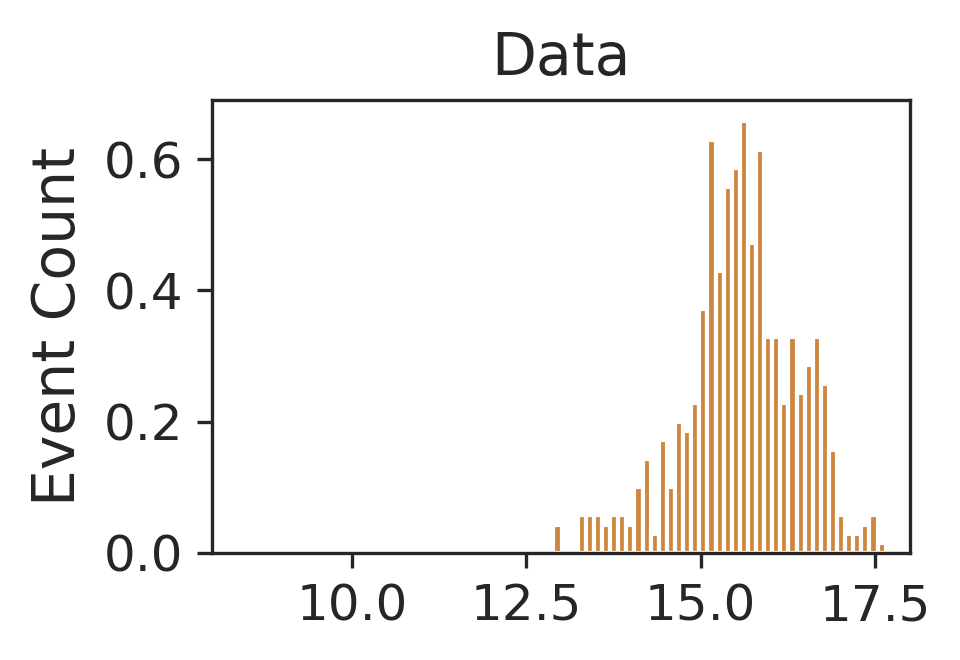

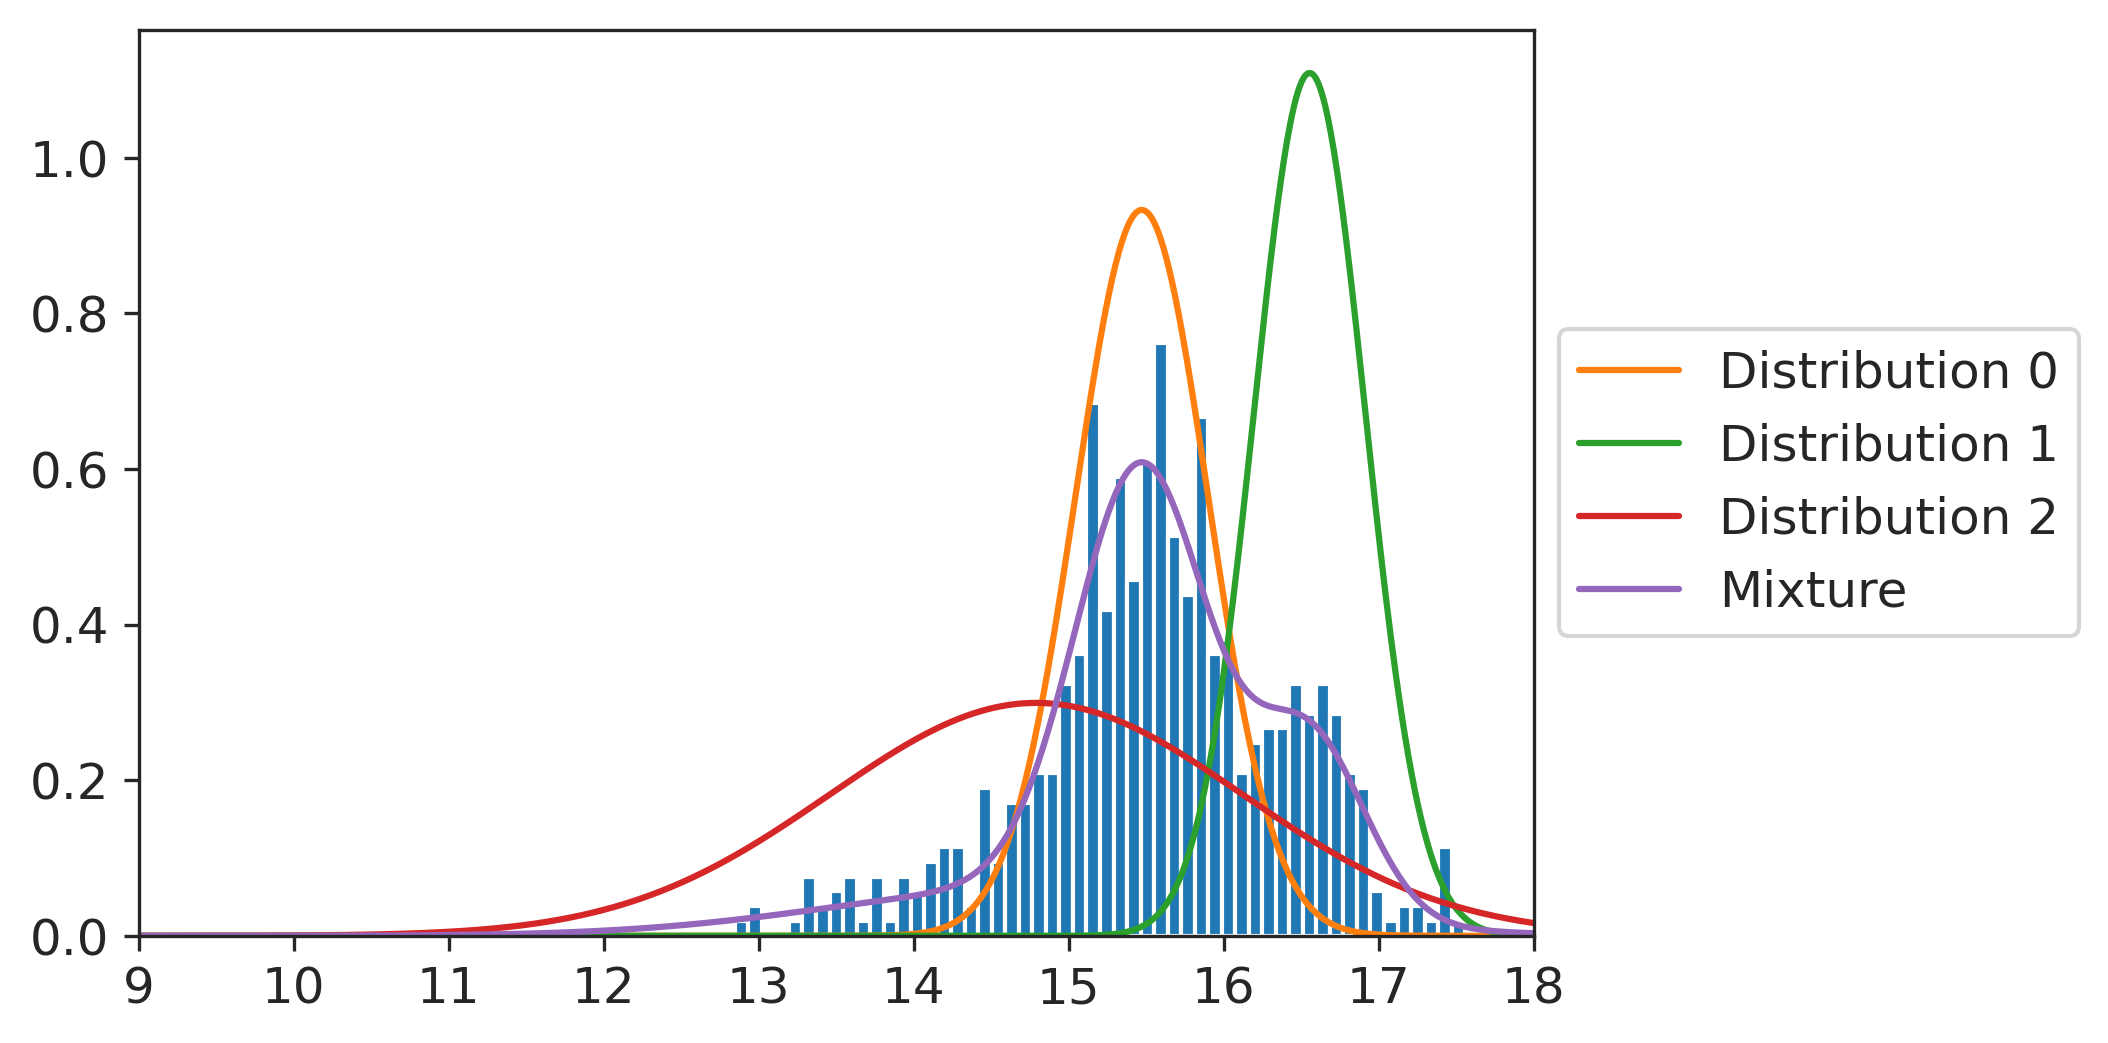

In [108]:
Sort = '1st_peak'
probs, model, df = glmCellTrace(adata.obs, 3, Sort)

In [111]:
probability_df = pd.DataFrame(probs)

# Most likely Distribution
MostLikelyDist= probability_df.T.idxmax()

# Dictionary which I make for each to assign distribution to division peak
dist_to_division = {0: '1', 1: '0', 2: '3', 3: '?'}

divSeries = MostLikelyDist.map(dist_to_division)

_df = pd.DataFrame(divSeries)
_df.columns = ['DivisionNumber']

_df.set_index(df.index, inplace = True)

__df = pd.merge(df, _df, left_index=True, right_index=True)

__df_Sister = __df

In [112]:
probs

array([[2.98097119e-02, 5.42174952e-11, 9.70190288e-01],
       [7.38135554e-01, 8.00585609e-06, 2.61856441e-01],
       [1.10759018e-01, 7.96552523e-01, 9.26884593e-02],
       ...,
       [8.95555860e-01, 5.97610066e-04, 1.03846530e-01],
       [8.83756122e-01, 3.01467753e-04, 1.15942410e-01],
       [3.04534270e-01, 5.87899255e-01, 1.07566476e-01]])

In [117]:
#__df_Sister.rename({'DivisionNumber_y': 'DivisionNumber'}, axis = 1, inplace=True)

/home/mswift/local/anaconda3/envs/pom/lib/python3.8/site-packages/pandas/core/series.py:679: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


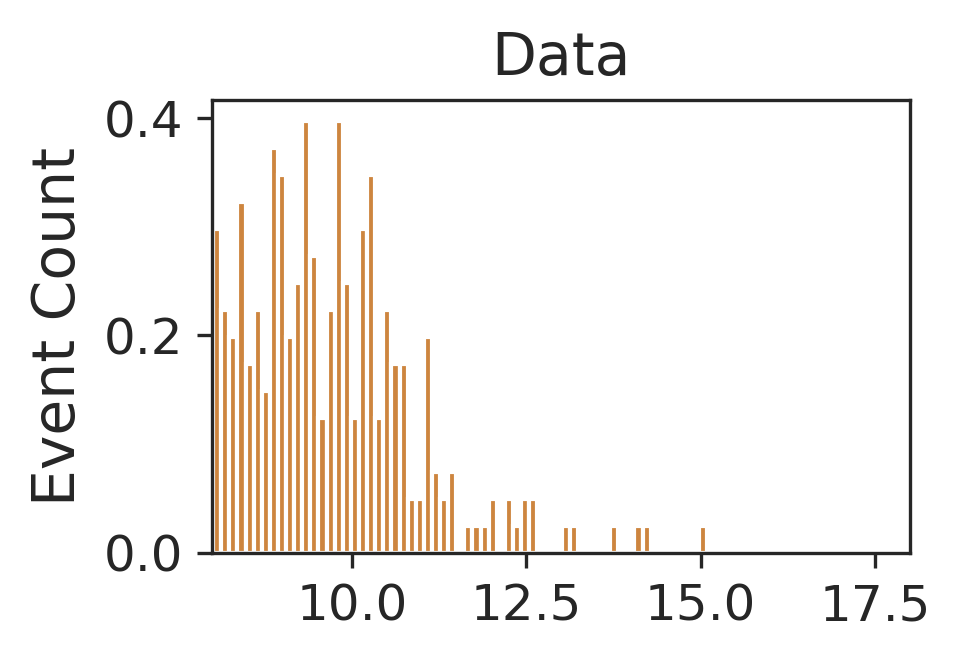

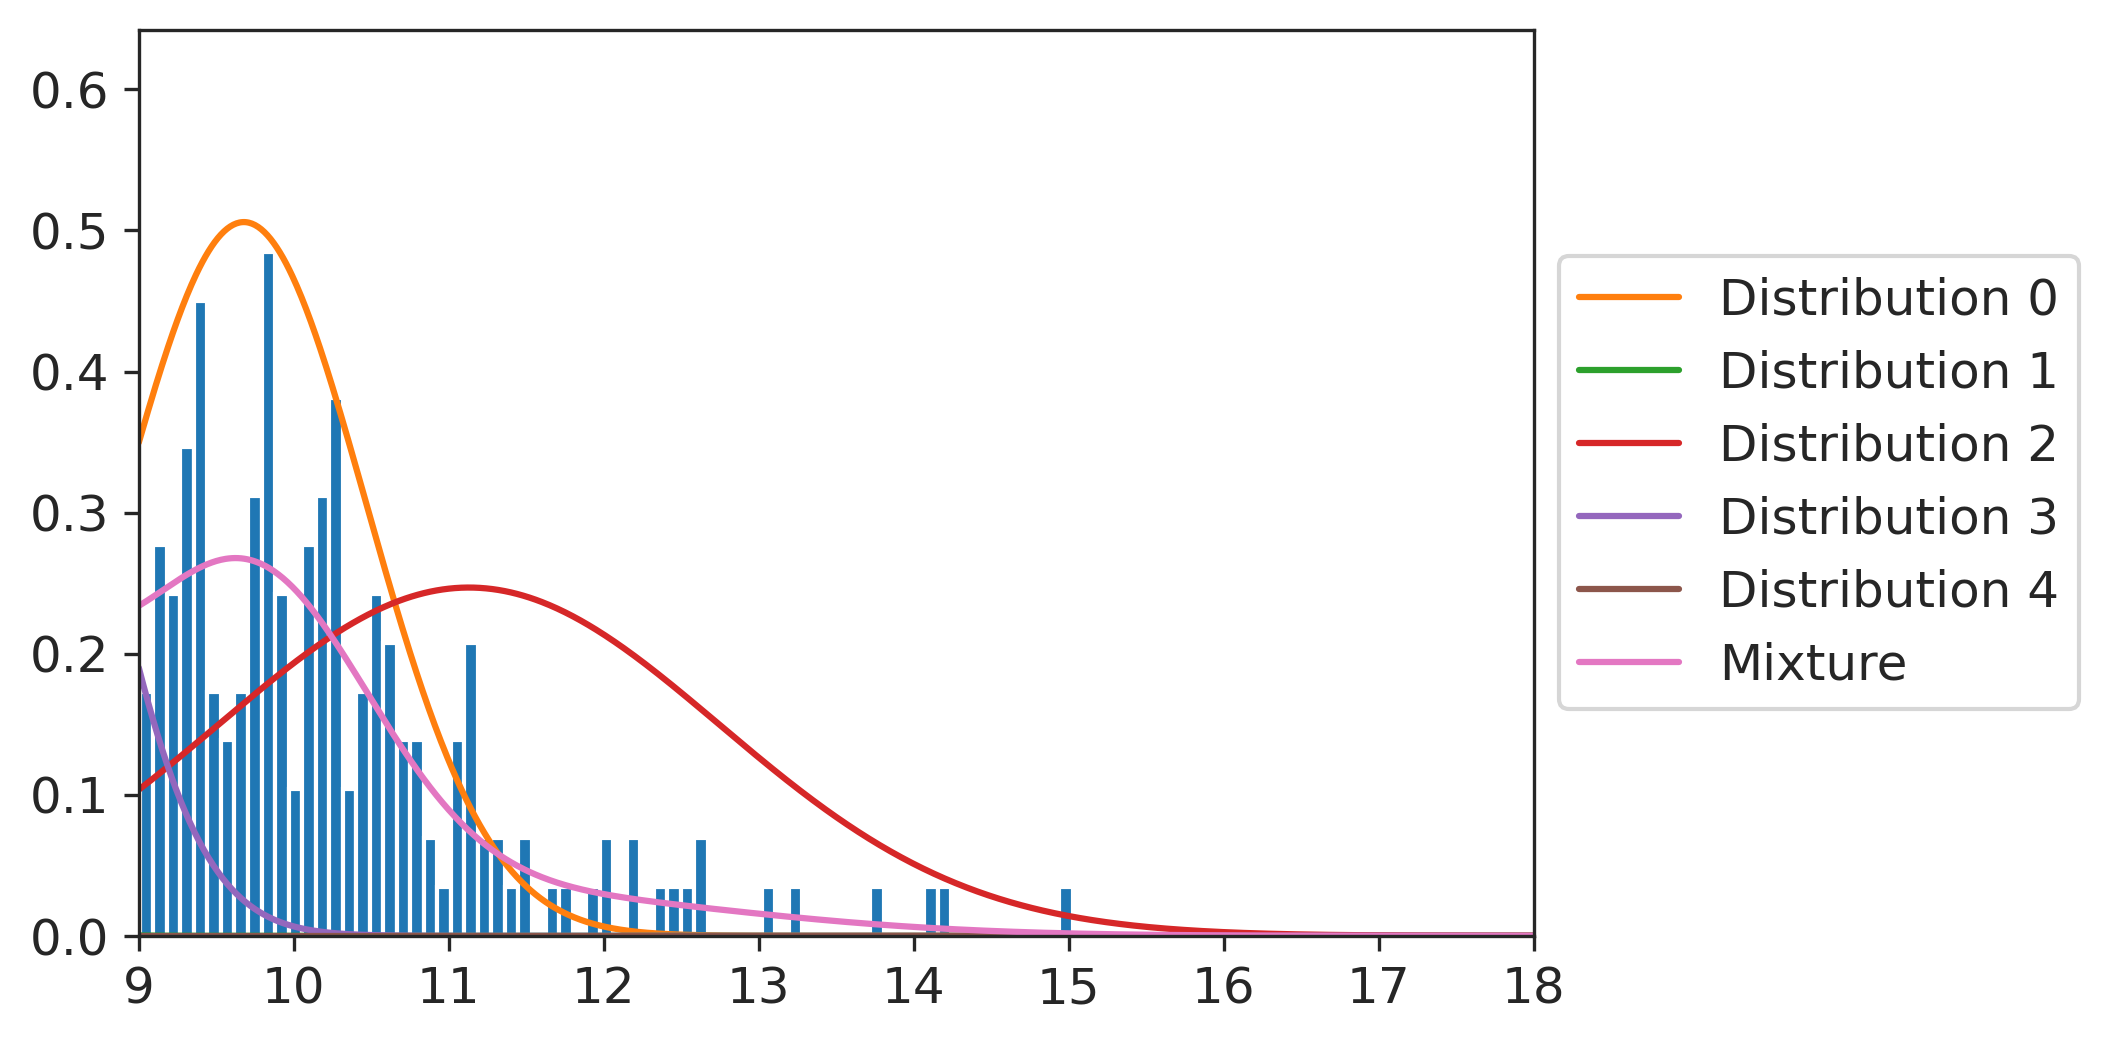

In [11]:
Sort = 'CTV+2'
probs, model, df = glmCellTrace(adata.obs, 5, Sort)

In [12]:
probability_df = pd.DataFrame(probs)

# Most likely Distribution
MostLikelyDist= probability_df.T.idxmax()

# Dictionary which I make for each to assign distribution to division peak
dist_to_division = {0: 'Max', 1: 'Max', 2: '5', 3: 'Max', 4:'Max'}

divSeries = MostLikelyDist.map(dist_to_division)

_df = pd.DataFrame(divSeries)
_df.columns = ['DivisionNumber']

_df.set_index(df.index, inplace = True)

__df = pd.merge(df, _df, left_index=True, right_index=True)

In [13]:
_dfCTY2 = __df

### CTY

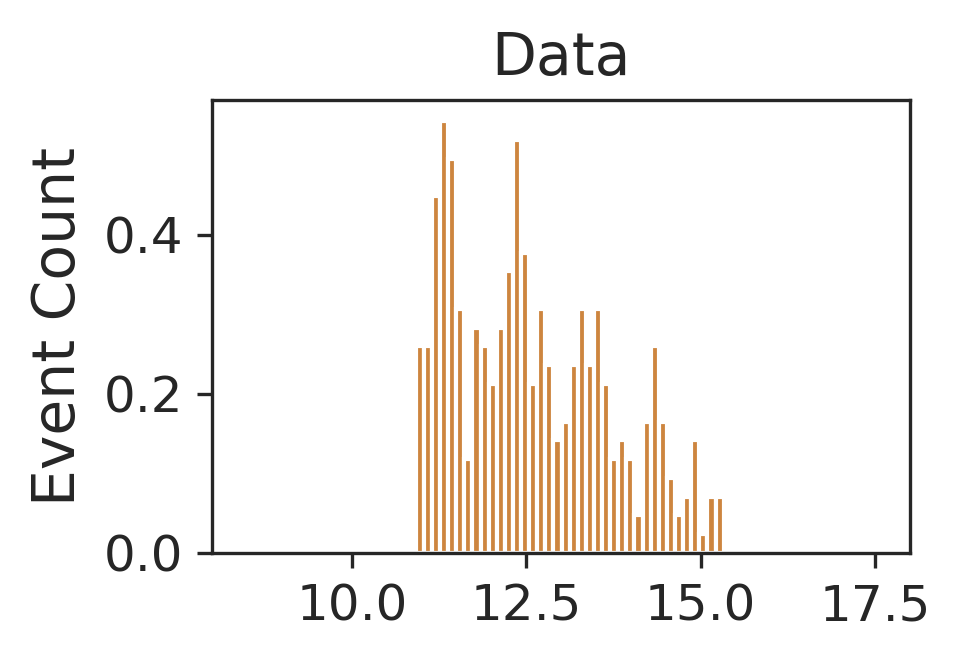

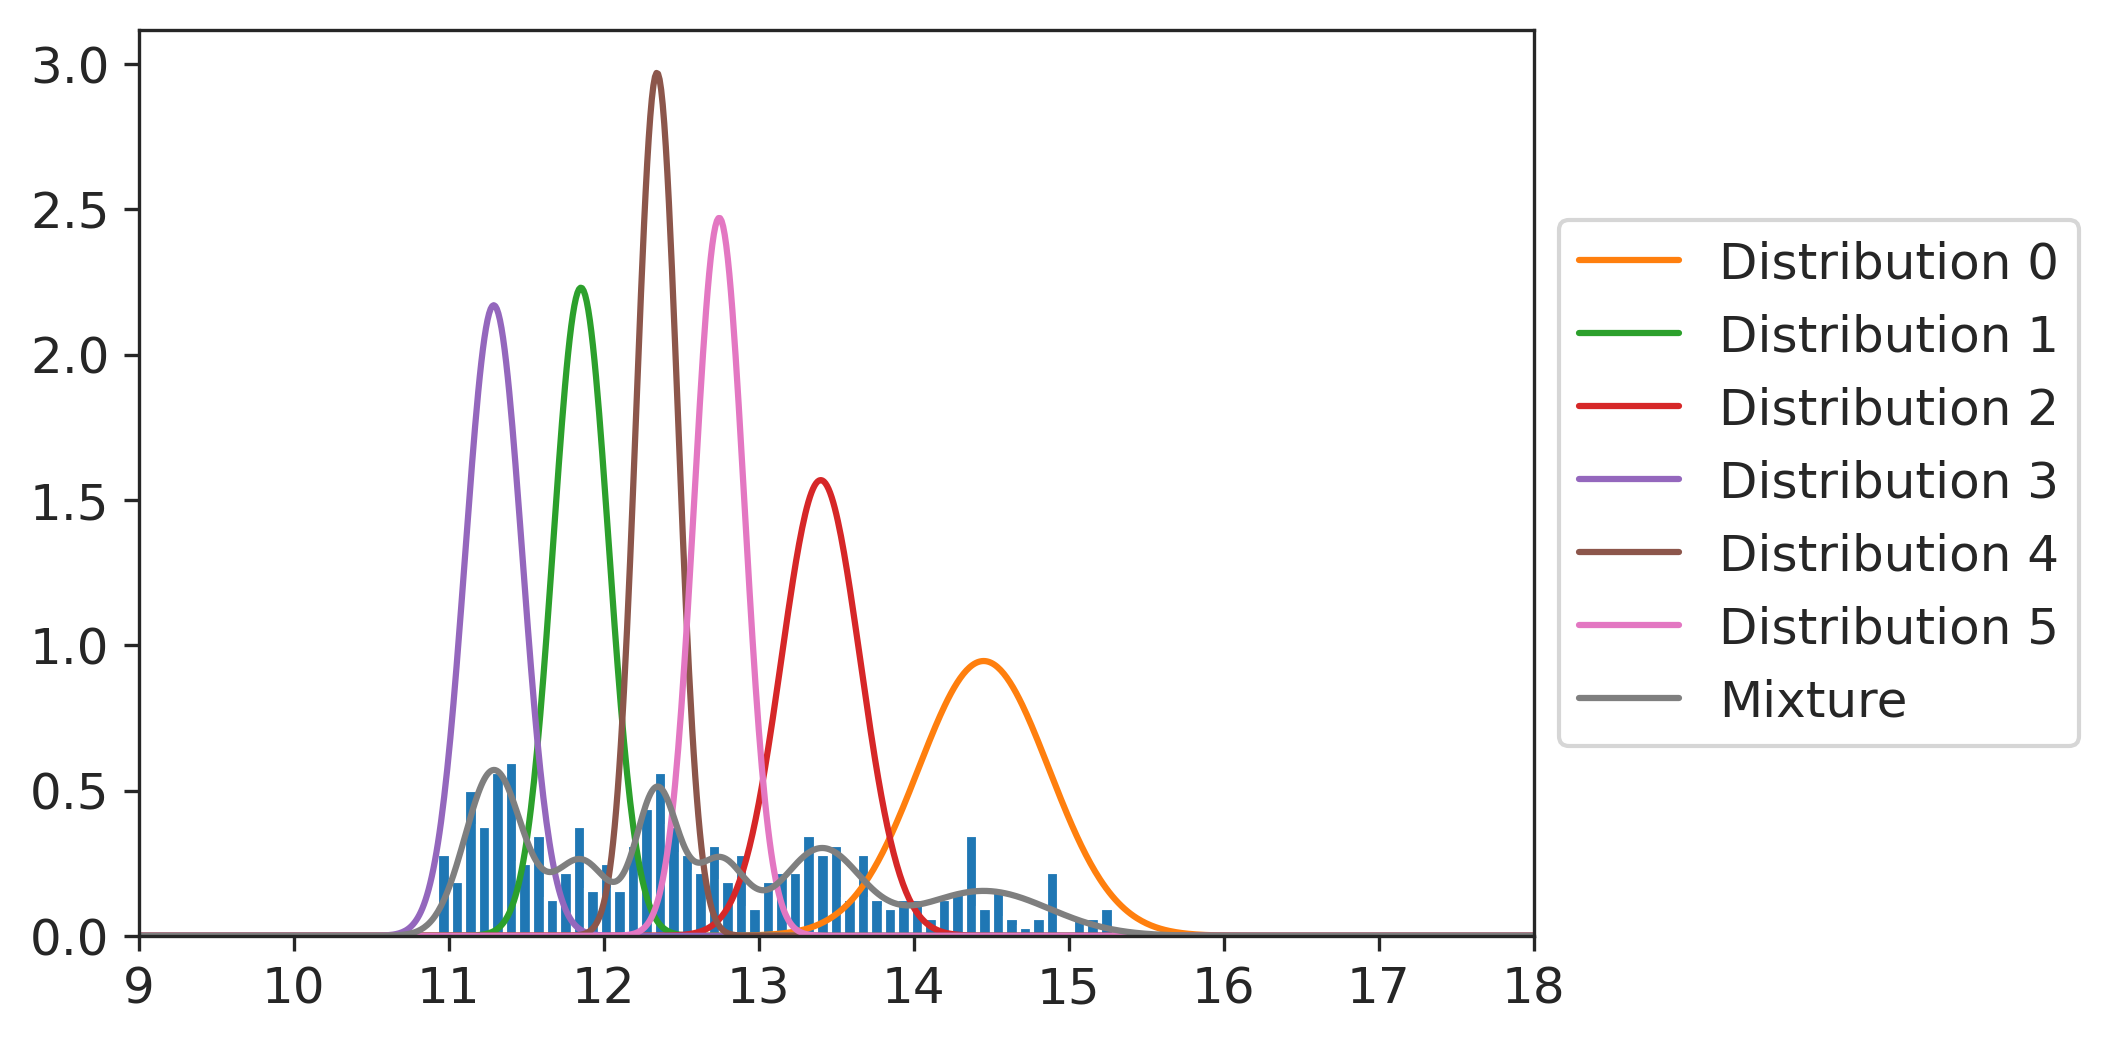

In [14]:
Sort = 'CTY'
probs, model, df = glmCellTrace(adata.obs, 6, Sort)

In [68]:
probability_df.shape 

(373, 5)

In [15]:
probability_df = pd.DataFrame(probs)

# Most likely Distribution
MostLikelyDist= probability_df.T.idxmax()

# Dictionary which I make for each to assign distribution to division peak
dist_to_division = {0: '2', 1: '6', 2: '3', 3: 'Max', 4:'5', 5:'4'}

divSeries = MostLikelyDist.map(dist_to_division)

_df = pd.DataFrame(divSeries)
_df.columns = ['DivisionNumber']

_df.set_index(df.index, inplace = True)

__df = pd.merge(df, _df, left_index=True, right_index=True)

In [16]:
_dfCTY = __df

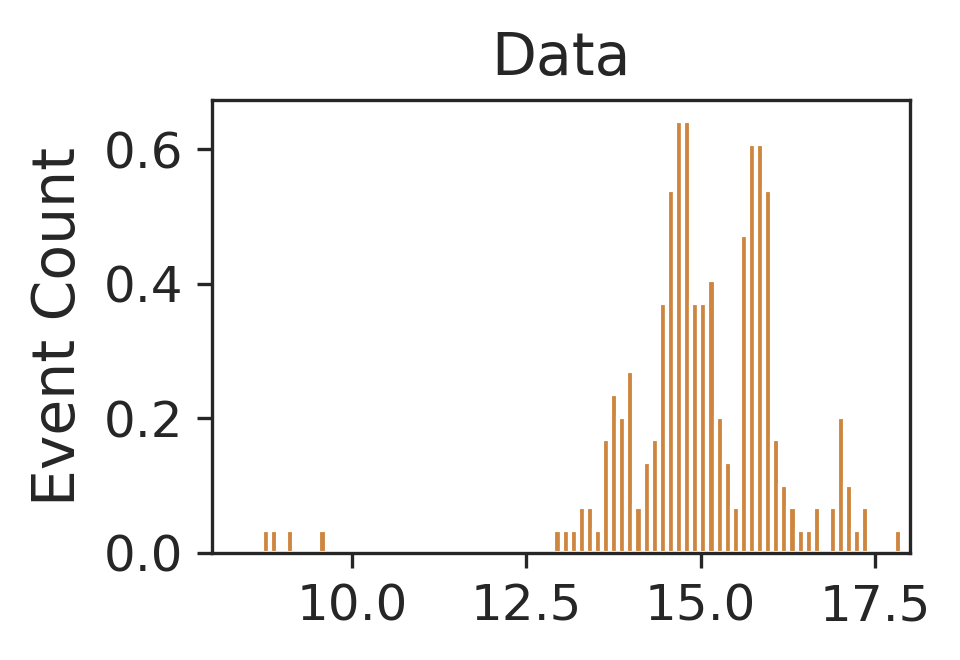

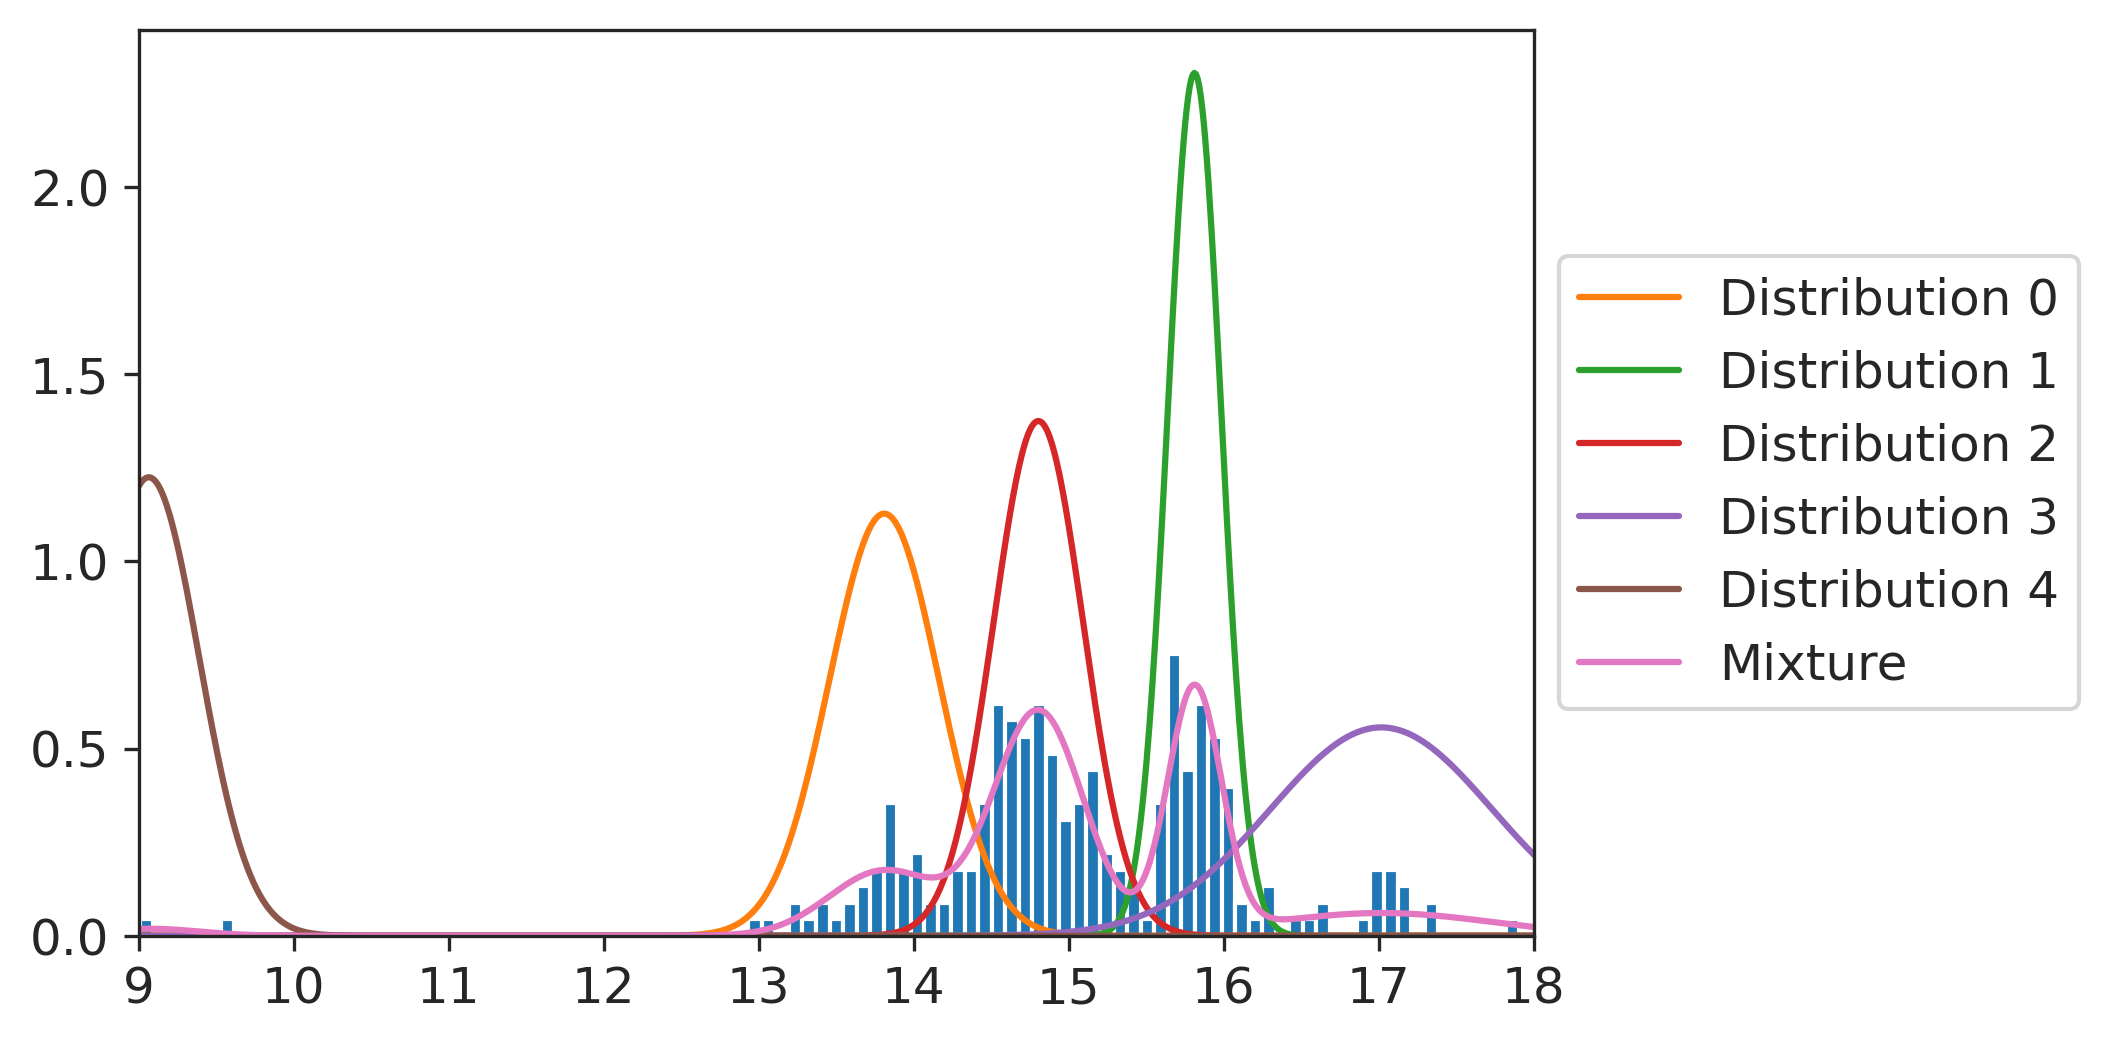

In [18]:
## CTV
Sort = 'CTV+'
probs, model, df = glmCellTrace(adata.obs, 5, Sort)

In [19]:
probability_df = pd.DataFrame(probs)

# Most likely Distribution
MostLikelyDist= probability_df.T.idxmax()

# Dictionary which I make for each to assign distribution to division peak
dist_to_division = {0: '3', 1: '1', 2: '2', 3: '0', 4:'Max'}

divSeries = MostLikelyDist.map(dist_to_division)

_df = pd.DataFrame(divSeries)
_df.columns = ['DivisionNumber']

_df.set_index(df.index, inplace = True)

__df = pd.merge(df, _df, left_index=True, right_index=True)

In [20]:
_df_SplitsortCTVplus = __df

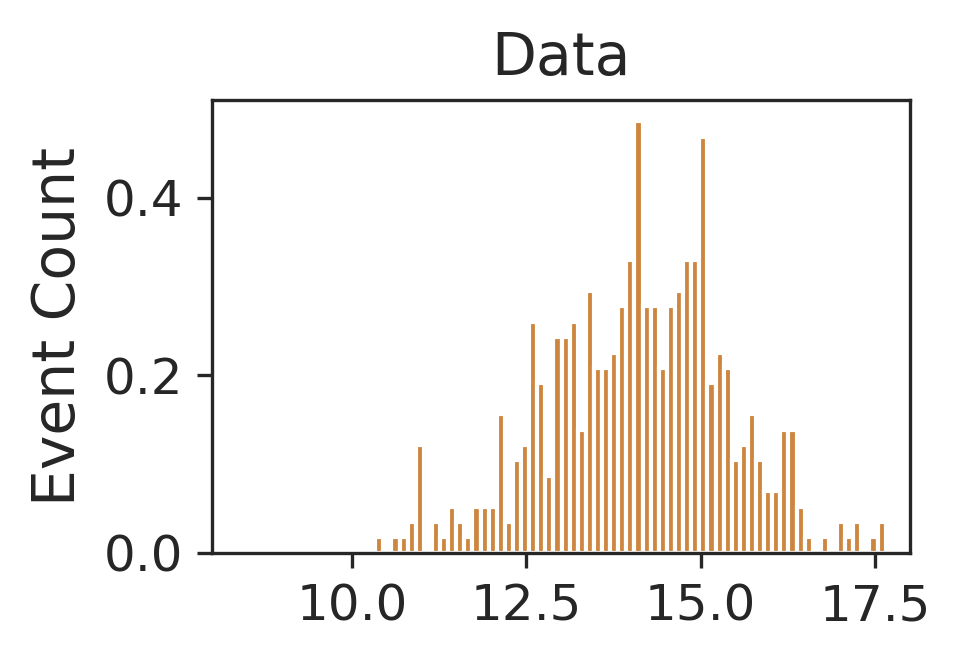

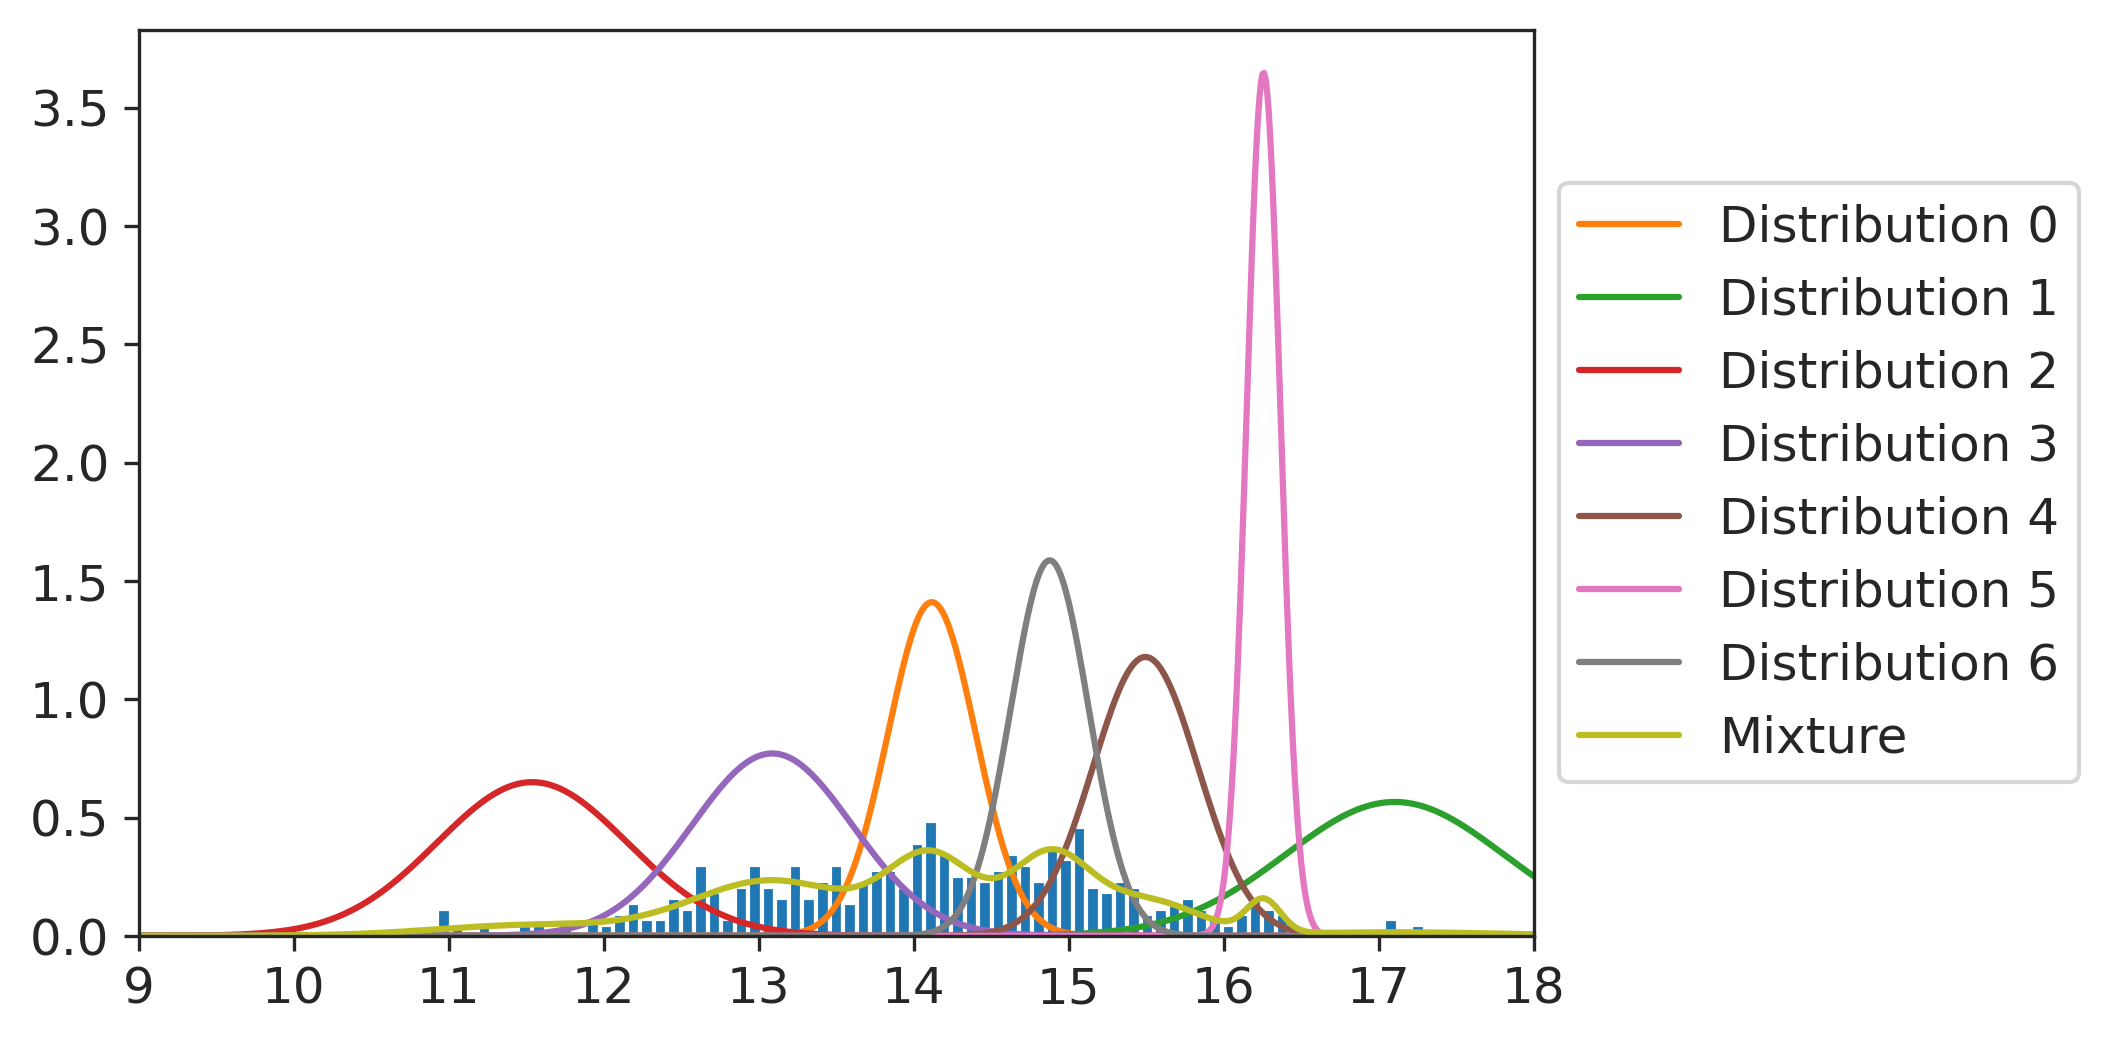

In [21]:
## CTV
Sort = 'Reg_IL_split'
probs, model, df = glmCellTrace(adata.obs, 7, Sort)

In [22]:
probability_df = pd.DataFrame(probs)

# Most likely Distribution
MostLikelyDist= probability_df.T.idxmax()

# Dictionary which I make for each to assign distribution to division peak
dist_to_division = {0: '4', 1: '0', 2:'Max', 3: '5', 4:'2', 5:'1', 6:'3'}

divSeries = MostLikelyDist.map(dist_to_division)

_df = pd.DataFrame(divSeries)
_df.columns = ['DivisionNumber']

_df.set_index(df.index, inplace = True)

__df = pd.merge(df, _df, left_index=True, right_index=True)

In [23]:
_df_REGILSPLIT = __df

In [25]:
_df_REGILSPLIT.shape

(497, 95)

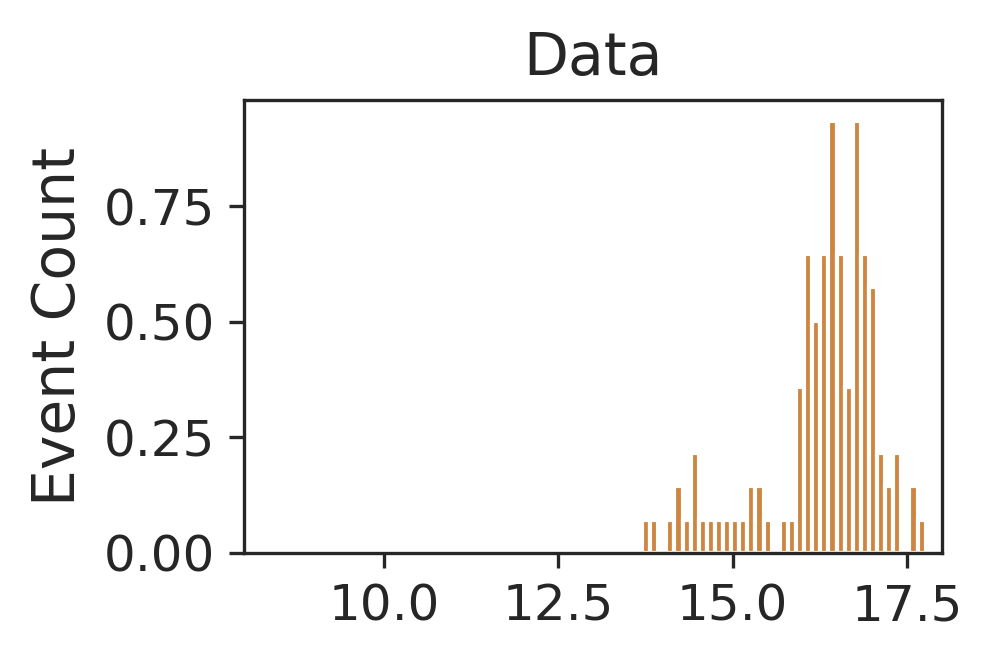

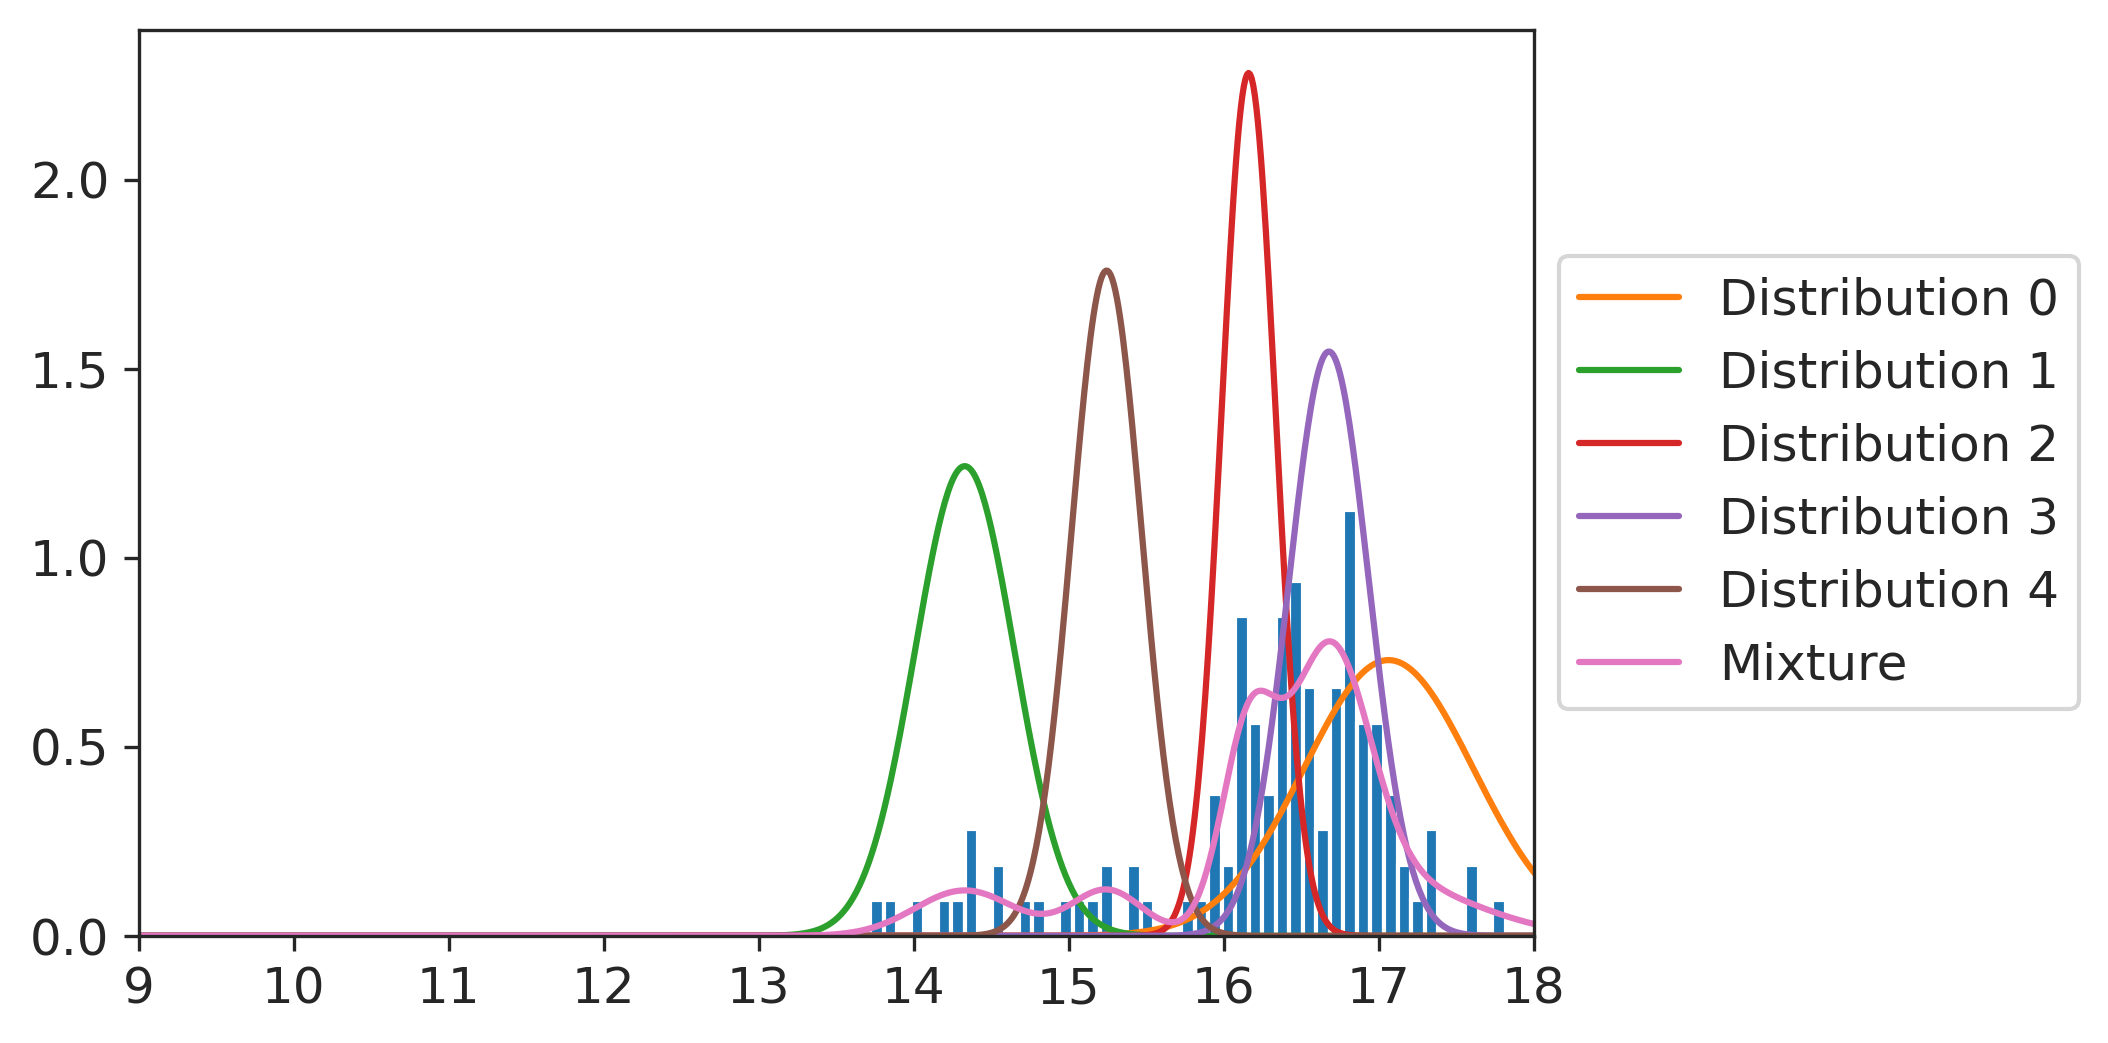

In [27]:
### EtBr- CTV+

## CTV
Sort = 'EtBr-_CTV+'
probs, model, df = glmCellTrace(adata.obs, 5, Sort)

In [28]:
probability_df = pd.DataFrame(probs)

# Most likely Distribution
MostLikelyDist= probability_df.T.idxmax()

# Dictionary which I make for each to assign distribution to division peak
dist_to_division = {0: '0', 1: '4', 2: '2', 3: '1', 4: '3'}

divSeries = MostLikelyDist.map(dist_to_division)

_df = pd.DataFrame(divSeries)
_df.columns = ['DivisionNumber']

_df.set_index(df.index, inplace = True)

__df = pd.merge(df, _df, left_index=True, right_index=True)

In [29]:
_dfOtherSister = __df

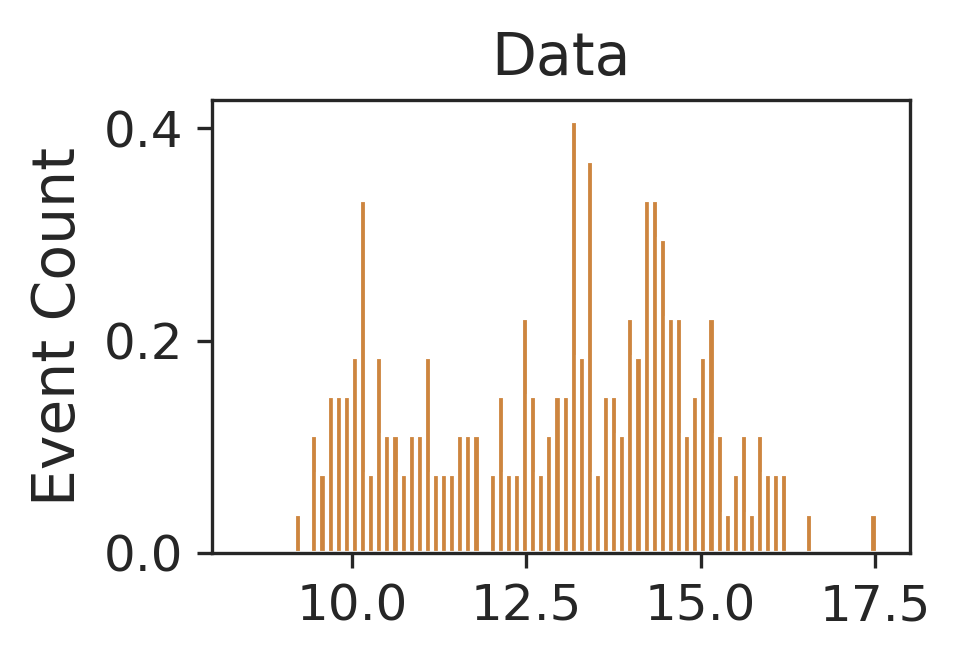

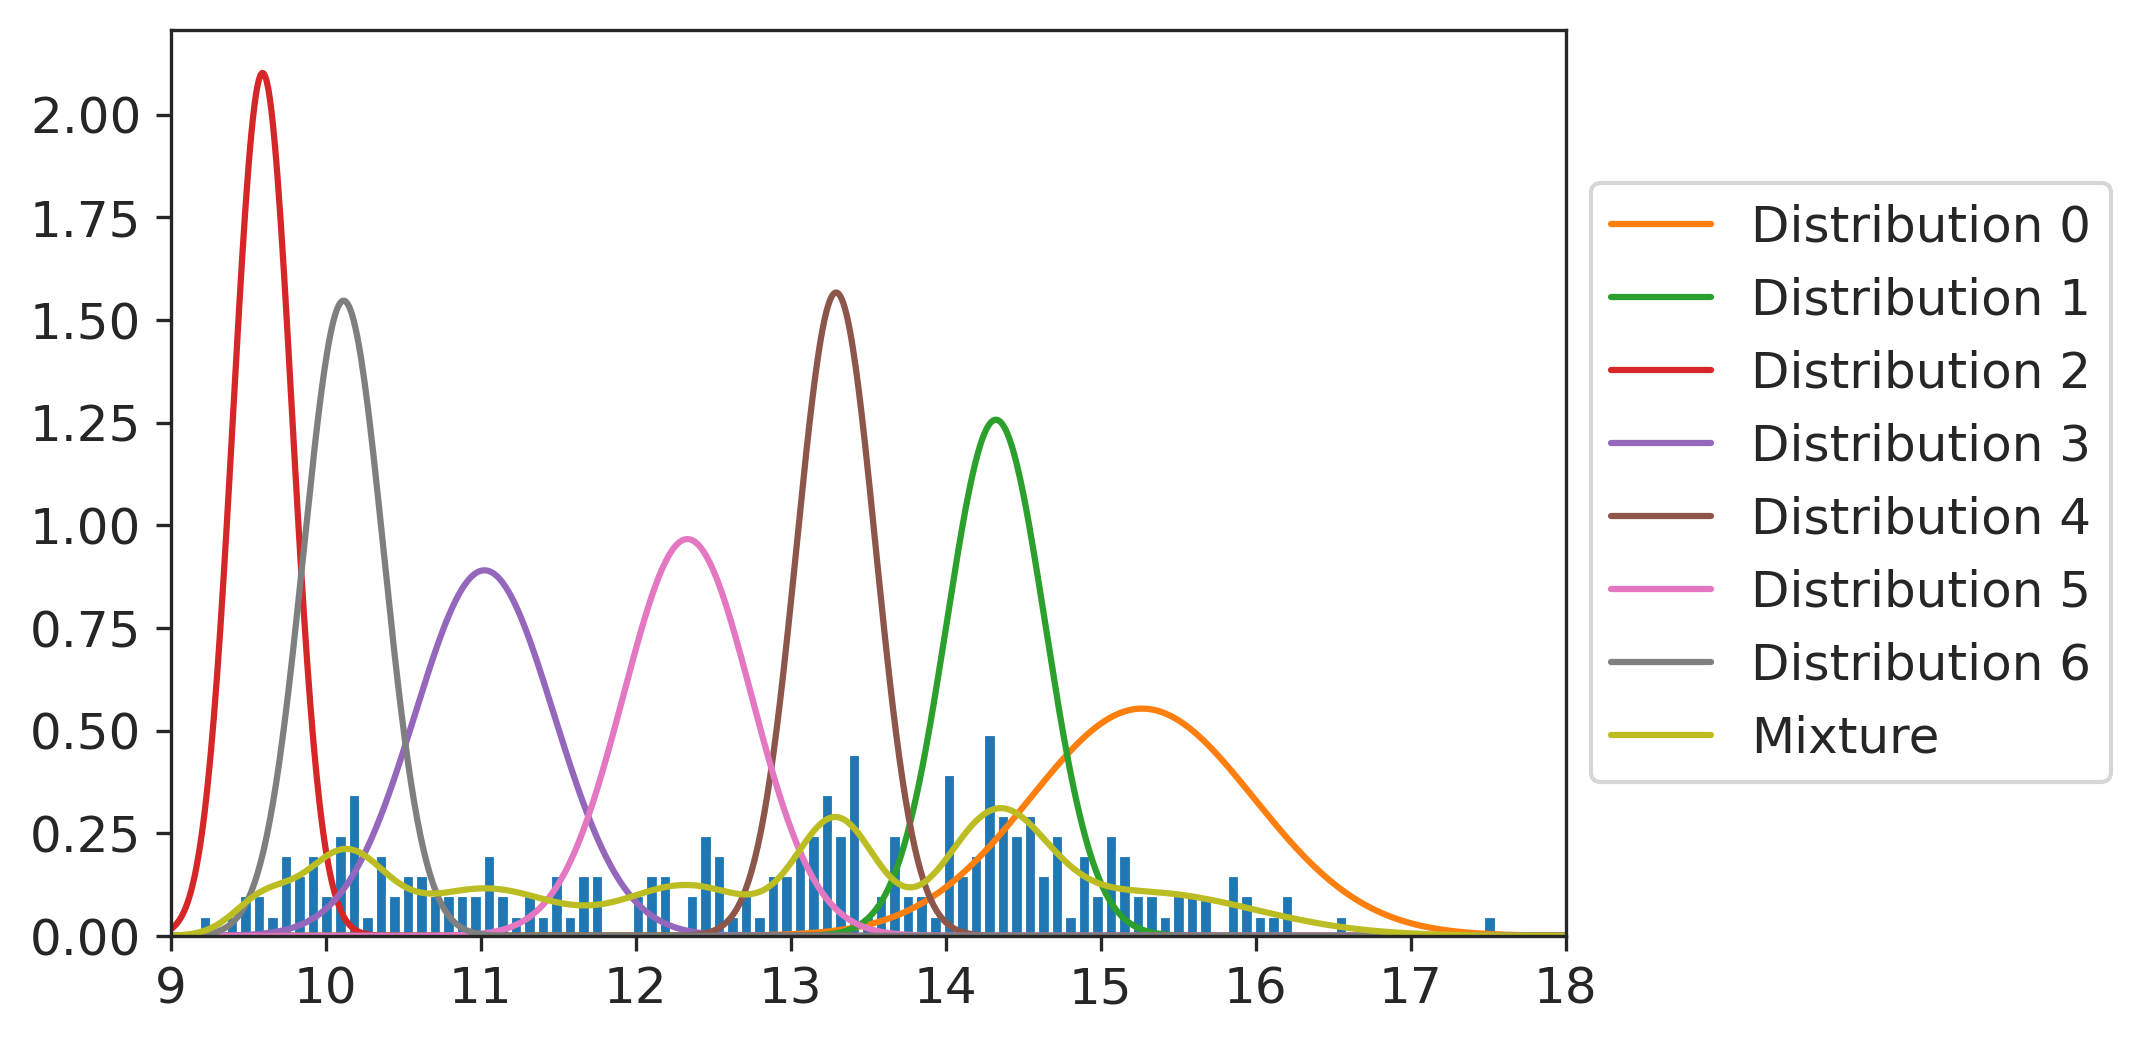

In [31]:
Sort = 'C8_unrelatedwell'
## CTV
probs, model, df = glmCellTrace(adata.obs, 7, Sort)

In [32]:
probability_df = pd.DataFrame(probs)

# Most likely Distribution
MostLikelyDist= probability_df.T.idxmax()

# Dictionary which I make for each to assign distribution to division peak
dist_to_division = {0: '2', 1: '3', 2: 'Max', 3: '6', 4:'4', 5: '5' , 6: 'Max'}

divSeries = MostLikelyDist.map(dist_to_division)

_df = pd.DataFrame(divSeries)
_df.columns = ['DivisionNumber']

_df.set_index(df.index, inplace = True)

__df = pd.merge(df, _df, left_index=True, right_index=True)

In [33]:
_dfC8 = __df

In [118]:
# Concatenate list of all the dfs I've now generated

divNumber = pd.concat([_df_REGILSPLIT, _df_SplitsortCTVplus, _dfC8, _dfCTY, _dfOtherSister, __df_Sister, _dfCTY2])

In [119]:
_dfOtherSister.shape

(122, 95)

In [134]:
divNumber.to_csv('../../data/DivisionCallingAdataObs.csv')

In [124]:
divNumberSeries = divNumber['DivisionNumber']

In [125]:
divNumberSeries

MS_IL4_F11              3
MS_IL4_F1             Max
MS_IL4_L6               4
MS_IL4_J12            Max
MS_IL4_G17              5
                     ... 
P1_CTV_5_15_19_G5     Max
P1_CTV_5_15_19_I17    Max
P1_CTV_5_15_19_O21    Max
P1_CTV_5_15_19_M19    Max
P1_CTV_5_15_19_E11    Max
Name: DivisionNumber, Length: 2452, dtype: object

In [126]:
adata.obs['DivisionNumber'] = 'None'

celldict = divNumberSeries.to_dict()
# Set temporary cell name column to map to
adata.obs['temp'] = adata.obs.index
# Map
adata.obs['temp'] = adata.obs['temp'].map(celldict)
# Fill Na with None
adata.obs['temp'].fillna(adata.obs['DivisionNumber'], inplace = True)

adata.obs['DivisionNumber'] = adata.obs['temp']

In [128]:
adata.obs.loc[:,'DivisionNumber'][adata.obs.Sort.str.contains('IgE')] = 'Max'
adata.obs.loc[:,'DivisionNumber'][adata.obs.Sort.str.contains('BSC')] = 'No Tracking'

<ipython-input-128-0c98d279200a>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata.obs.loc[:,'DivisionNumber'][adata.obs.Sort.str.contains('IgE')] = 'Max'
<ipython-input-128-0c98d279200a>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata.obs.loc[:,'DivisionNumber'][adata.obs.Sort.str.contains('BSC')] = 'No Tracking'


In [130]:
selector = adata.obs[(adata.obs.Condition_Labels == 'Activation')
          & (adata.obs.DivisionNumber == 'None')].index

In [131]:
divNumber.Sort.value_counts()

1st_peak            603
Reg_IL_split        497
CTV+2               373
CTY                 365
CTV+                259
C8_unrelatedwell    233
EtBr-_CTV+          122
None                  0
IgG+,IgE+,CD19+       0
BSC/FSC               0
Name: Sort, dtype: int64

In [132]:
divNumber[divNumber.index.isin(selector)].Sort.value_counts()

Reg_IL_split        0
None                0
IgG+,IgE+,CD19+     0
EtBr-_CTV+          0
CTY                 0
CTV+2               0
CTV+                0
C8_unrelatedwell    0
BSC/FSC             0
1st_peak            0
Name: Sort, dtype: int64

In [133]:
adata.write_h5ad('/home/mswift/B_cells/CSR/switchy/data/CombinedDivision.h5ad')

... storing 'DivisionNumber' as categorical
... storing 'temp' as categorical


In [388]:
# Investigate source of unexpected Nones
dklskl = adata.obs[adata.obs.Exp_Labels.str.contains('Activation')]
dklskl = dklskl[~dklskl.Exp_Labels.str.contains('Activation_0')]

In [389]:
adf = dklskl[dklskl.DivisionNumber == 'None']

In [390]:
adf = adf[adf.Exp_Labels == 'Activation_4']

In [391]:
lala = adata.obs[adata.obs.Exp_Labels.str.contains('Activation_4')]

In [392]:
lala.reset_index()['index'].str.rsplit('_', n = 1, expand = True)[0].value_counts()

P1_CTV_5_15_19    384
P1_5_23_19_D2     384
Name: 0, dtype: int64